# Customer Segmentation — Manual Approach
**Goal:** segment customers using unsupervised ML and compare clustering algorithms (KMeans, Agglomerative, DBSCAN, GMM, Spectral), tune hyperparams manually, evaluate with internal metrics, visualize in 2D/3D, and produce cluster profiles.

## package Import

In [1]:
from pathlib import Path
import joblib
from datetime import datetime

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
def find_project_root(path):
    """Find the root directory of a Git repository."""
    path = Path(path).resolve()
    while True:
        if (path / '.git').exists():
            return path
        if path.parent == path:
            break
        path = path.parent
    return None


In [4]:
# Find the root directory of the project
CURR_DIR = Path().resolve()
ROOT_DIR = find_project_root(CURR_DIR)

# Define the data directory
DATA_DIR = ROOT_DIR / 'data'

In [5]:
# Load the customer data
customer_data = pd.read_csv(DATA_DIR / 'raw_data' / 'mall_customers.csv')

# Create a copy of the data
df = customer_data.copy(deep=True)


In [6]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [7]:
# normalize column names for convenience
df = df.rename(columns={
    'CustomerID': 'CustomerID',
    'Gender': 'Gender',
    'Age': 'Age',
    'Annual Income (k$)': 'AnnualIncome',
    'Spending Score (1-100)': 'SpendingScore'
})

In [8]:
df['AnnualIncome'] = df['AnnualIncome']*1000

## EDA (Exploratory Data Analysis)

In [9]:
df.head()

,CustomerID,Gender,Age,AnnualIncome,SpendingScore
0,1,Male,19,15000,39
1,2,Male,21,15000,81
2,3,Female,20,16000,6
3,4,Female,23,16000,77
4,5,Female,31,17000,40


In [10]:
df.tail()

,CustomerID,Gender,Age,AnnualIncome,SpendingScore
195,196,Female,35,120000,79
196,197,Female,45,126000,28
197,198,Male,32,126000,74
198,199,Male,32,137000,18
199,200,Male,30,137000,83


In [11]:

df.shape


(200, 5)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     200 non-null    int64 
 1   Gender         200 non-null    object
 2   Age            200 non-null    int64 
 3   AnnualIncome   200 non-null    int64 
 4   SpendingScore  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [13]:
# show class counts of categorical feature
print(df['Gender'].value_counts())

Gender
Female    112
Male       88
Name: count, dtype: int64


In [14]:
df.describe()

,CustomerID,Age,AnnualIncome,SpendingScore
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60560.000000,50.200000
std,57.879185,13.969007,26264.721165,25.823522
min,1.000000,18.000000,15000.000000,1.000000
25%,50.750000,28.750000,41500.000000,34.750000
50%,100.500000,36.000000,61500.000000,50.000000
75%,150.250000,49.000000,78000.000000,73.000000
max,200.000000,70.000000,137000.000000,99.000000


In [15]:
numerical_cols = [col for col in df.select_dtypes(include="number").columns if col != "CustomerID"]
categorical_cols = df.select_dtypes(include="object").columns.tolist()

print(f"numerical features: {numerical_cols}")
print(f"categorical features: {categorical_cols}")

numerical features: ['Age', 'AnnualIncome', 'SpendingScore']
categorical features: ['Gender']


Univariate

####  find the skewness and curtosis values of the numerical features

In [16]:
measure_of_shape = {}
for col in numerical_cols:
    shape = {}
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    
    shape["skew"] = skew
    shape["skew_description"] = "right_skewed" if skew > 0 else "left_skewed"
    
    shape["kurt"] = kurt
    shape["kurt_description"] = (
        "plati-kurtic" if kurt < 3 
        else "meso-kurtic" if kurt == 3 
        else "lepto-kurtic"
    )
    
    measure_of_shape[col] = shape


measure_of_shape

{'Age': {'skew': 0.48556885096681657,
  'skew_description': 'right_skewed',
  'kurt': -0.6715728615981695,
  'kurt_description': 'plati-kurtic'},
 'AnnualIncome': {'skew': 0.3218425498619057,
  'skew_description': 'right_skewed',
  'kurt': -0.09848708652696203,
  'kurt_description': 'plati-kurtic'},
 'SpendingScore': {'skew': -0.047220201374263374,
  'skew_description': 'left_skewed',
  'kurt': -0.8266291062061502,
  'kurt_description': 'plati-kurtic'}}

In [17]:
measure_of_shape = {}
for col in numerical_cols:
    shape = {}
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    
    shape["skew"] = skew
    if skew < -1:
        shape["skew_description"] = "Highly left-skewed"
    elif skew < -0.5:
        shape["skew_description"] = "Moderately left-skewed"
    elif skew < 0:
        shape["skew_description"] = "Slightly left-skewed"
    elif skew == 0:
        shape["skew_description"] = "Symmetric"
    elif skew < 0.5:
        shape["skew_description"] = "Slightly right-skewed"
    elif skew < 1:
        shape["skew_description"] = "Moderately right-skewed"
    else:
        shape["skew_description"] = "Highly right-skewed"
    
    shape["kurt"] = kurt
    if kurt < 2:
        shape["kurt_description"] = "Very platykurtic(flat)"
    elif kurt < 3:
        shape["kurt_description"] = "Platykurtic(less peaked)"
    elif kurt == 3:
        shape["kurt_description"] = "Mesokurtic(normal)"
    elif kurt < 4:
        shape["kurt_description"] = "Leptokurtic(more peaked)"
    else:
        shape["kurt_description"] = "Very leptokurtic(very peaked)"
    
    measure_of_shape[col] = shape

data_shape_df = pd.DataFrame(measure_of_shape)
data_shape_df

,Age,AnnualIncome,SpendingScore
skew,0.485569,0.321843,-0.04722
skew_description,Slightly right-skewed,Slightly right-skewed,Slightly left-skewed
kurt,-0.671573,-0.098487,-0.826629
kurt_description,Very platykurtic(flat),Very platykurtic(flat),Very platykurtic(flat)


In [49]:
measure_of_shape

{'Age': {'skew': 0.48556885096681657,
  'skew_description': 'Slightly right-skewed',
  'kurt': -0.6715728615981695,
  'kurt_description': 'Very platykurtic(flat)'},
 'AnnualIncome': {'skew': 0.3218425498619057,
  'skew_description': 'Slightly right-skewed',
  'kurt': -0.09848708652696203,
  'kurt_description': 'Very platykurtic(flat)'},
 'SpendingScore': {'skew': -0.047220201374263374,
  'skew_description': 'Slightly left-skewed',
  'kurt': -0.8266291062061502,
  'kurt_description': 'Very platykurtic(flat)'}}

Visualization

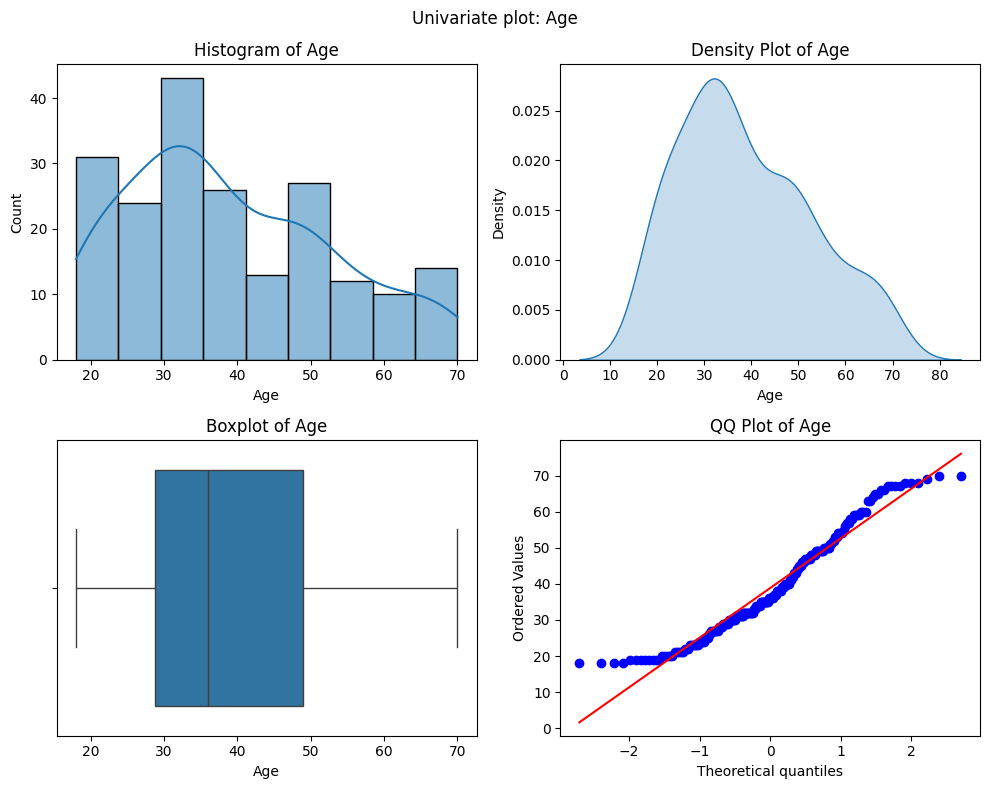

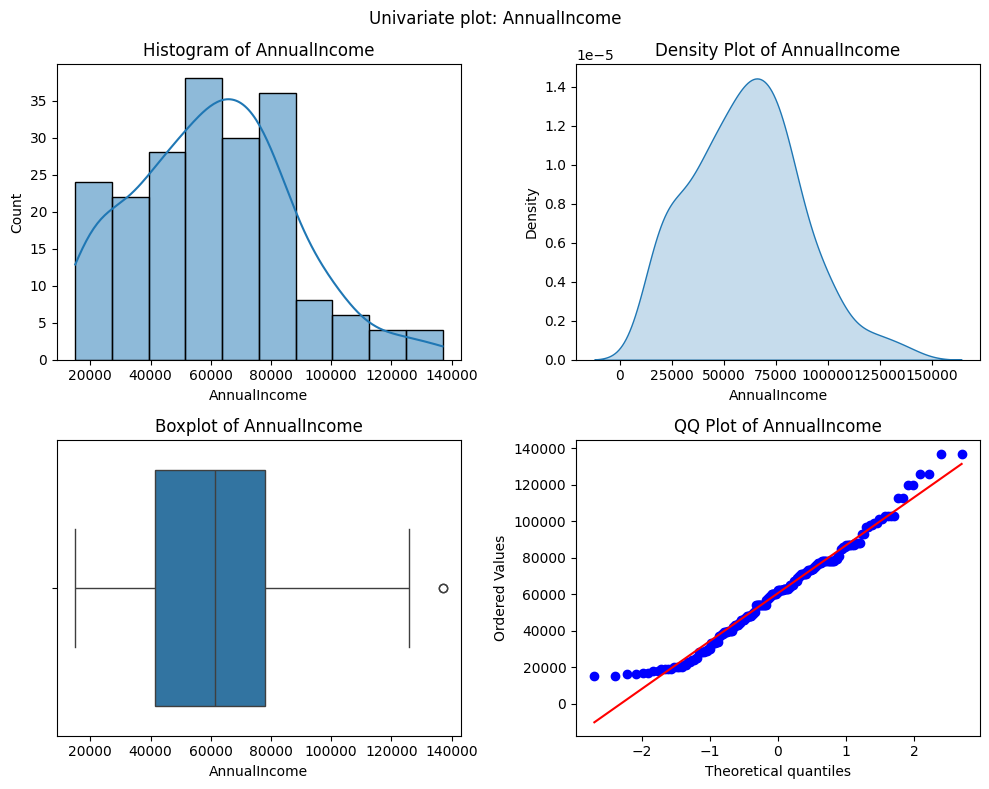

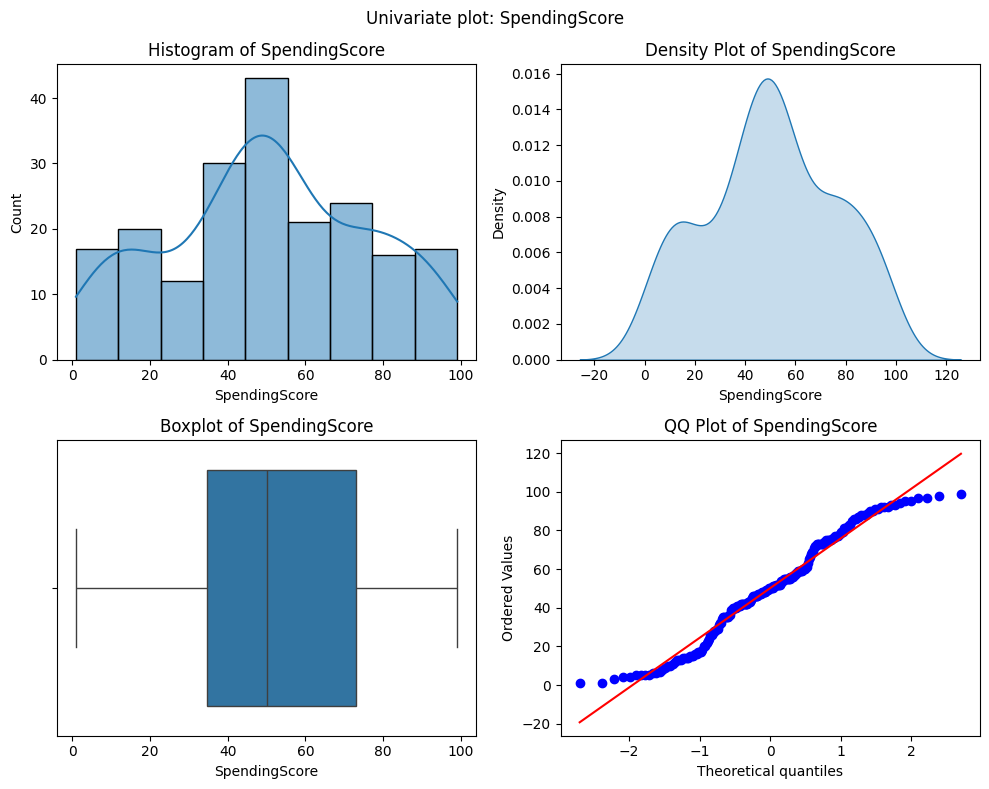

In [18]:


def univariate_plots(data: pd.DataFrame, feature: str) -> plt.subplot:
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
    
    # Histogram
    sns.histplot(data=data, x=feature, ax=axes[0, 0], kde=True)
    axes[0, 0].set_title(f"Histogram of {feature}")
    
    # Density Plot
    sns.kdeplot(data=data, x=feature, ax=axes[0, 1], fill=True)
    axes[0, 1].set_title(f"Density Plot of {feature}")
    
    # Boxplot
    sns.boxplot(data=data, x=feature, ax=axes[1, 0])
    axes[1, 0].set_title(f"Boxplot of {feature}")
    
    # QQ Plot
    # Note: Seaborn does not have a built-in QQ plot function.
    # We will use scipy.stats.probplot instead.
    from scipy import stats
    stats.probplot(data[feature], dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title(f"QQ Plot of {feature}")
    plt.suptitle(f"Univariate plot: {col}")
    
    plt.tight_layout()
    plt.show()


for col in numerical_cols:
    univariate_plots(df, col)

Bivariate


1. Numerical vs Numerical Analysis  
Numerical Messures

In [19]:
# Pearson's correlation matrix

corr_matrix_pearson = df[numerical_cols].corr(method='pearson')
print(f"pearson's correlation matrix:\n\n {corr_matrix_pearson}")

pearson's correlation matrix:

                     Age  AnnualIncome  SpendingScore
Age            1.000000     -0.012398      -0.327227
AnnualIncome  -0.012398      1.000000       0.009903
SpendingScore -0.327227      0.009903       1.000000


Multivariate

In [20]:
# Spearman's correlation matrix
corr_matrix_spearman = df[numerical_cols].corr(method='spearman')
print(f"spearman's correlation matrix:\n\n {corr_matrix_spearman}")

spearman's correlation matrix:

                     Age  AnnualIncome  SpendingScore
Age            1.000000      0.019767       -0.34494
AnnualIncome   0.019767      1.000000        0.00784
SpendingScore -0.344940      0.007840        1.00000


In [21]:
# kendall's Correlation matrix
corr_matrix_kendall = df[numerical_cols].corr(method='kendall')
print(f"kendall's correlation matrix:\n\n {corr_matrix_kendall}")

kendall's correlation matrix:

                     Age  AnnualIncome  SpendingScore
Age            1.000000      0.008198      -0.210757
AnnualIncome   0.008198      1.000000      -0.000765
SpendingScore -0.210757     -0.000765       1.000000


In [22]:
# Covariance matrix:
cov_matrix = df[numerical_cols].cov()
print(f"Covariance matrix:\n\n {cov_matrix}")

Covariance matrix:

                        Age  AnnualIncome  SpendingScore
Age             195.133166 -4.548744e+03    -118.040201
AnnualIncome  -4548.743719  6.898356e+08    6716.582915
SpendingScore  -118.040201  6.716583e+03     666.854271


Visualizations

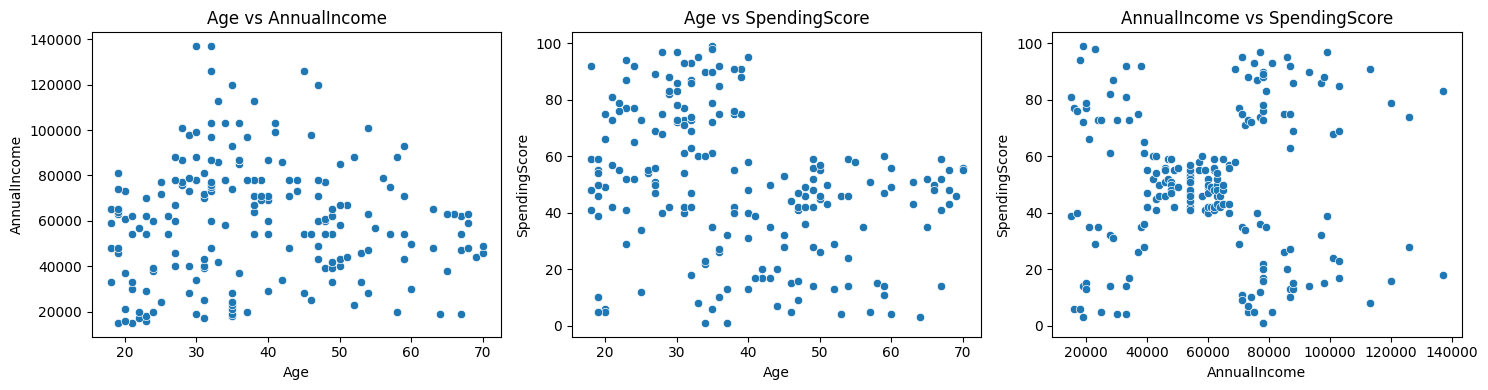

In [23]:
# Scatter plots
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.scatterplot(x='Age', y='AnnualIncome', data=df)
plt.title('Age vs AnnualIncome')

plt.subplot(1, 3, 2)
sns.scatterplot(x='Age', y='SpendingScore', data=df)
plt.title('Age vs SpendingScore')

plt.subplot(1, 3, 3)
sns.scatterplot(x='AnnualIncome', y='SpendingScore', data=df)
plt.title('AnnualIncome vs SpendingScore')

plt.tight_layout()
plt.show()

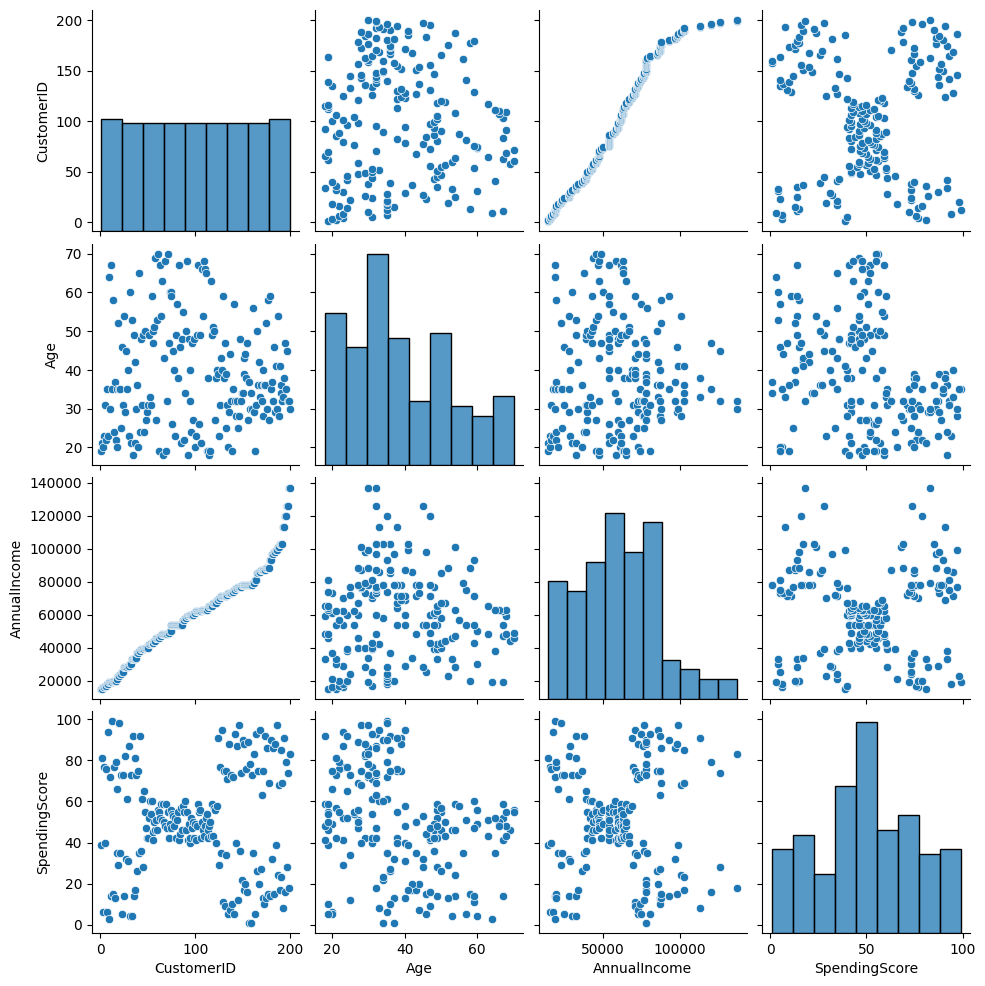

In [24]:
# Pairplot (all numerical combinations)
sns.pairplot(df)
plt.show()

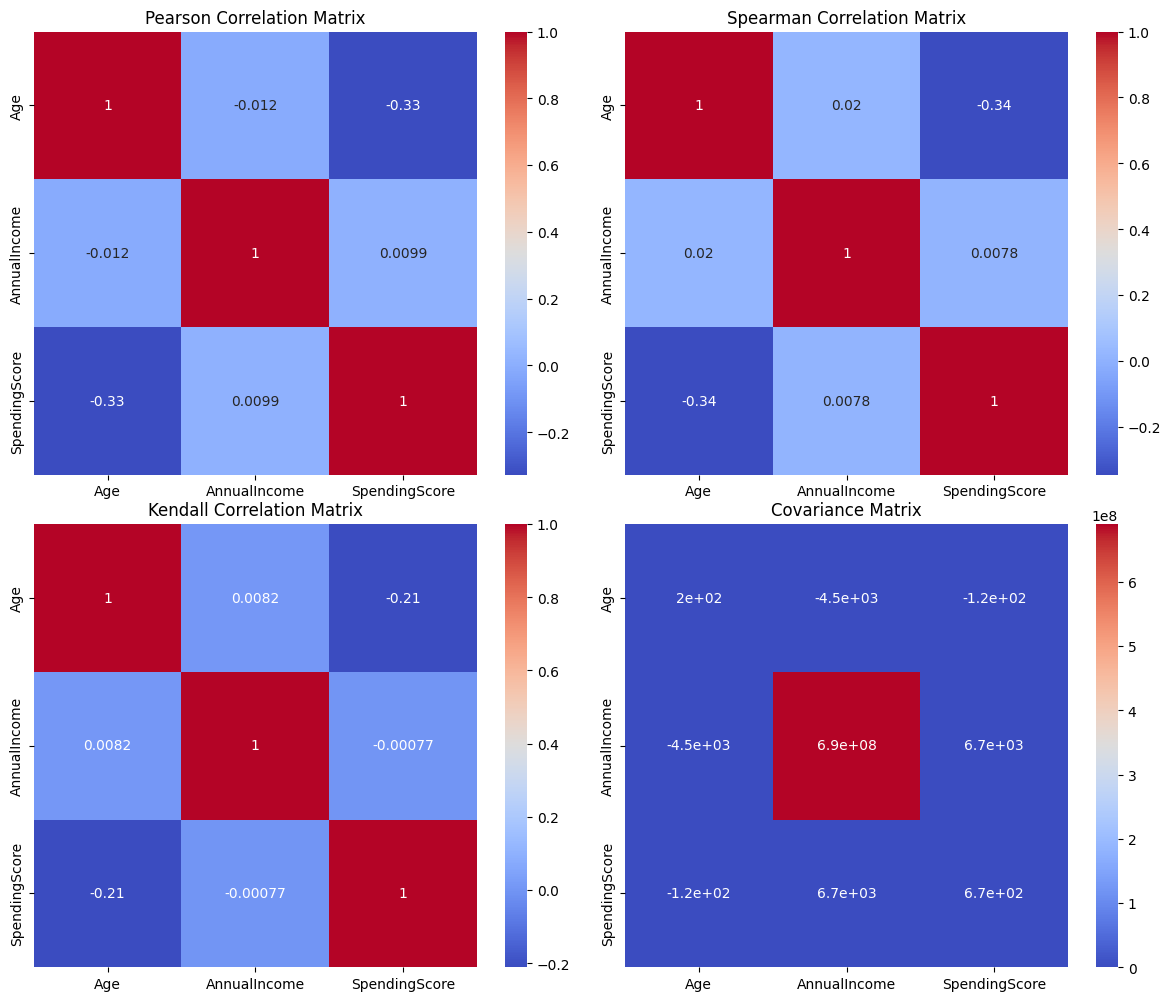

In [ ]:


# Create a 2x2 subplot
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Plot the Pearson correlation matrix
sns.heatmap(corr_matrix_pearson, annot=True, cmap='coolwarm', square=True, ax=axs[0, 0])
axs[0, 0].set_title('Pearson Correlation Matrix')

# Plot the Spearman correlation matrix
sns.heatmap(corr_matrix_spearman, annot=True, cmap='coolwarm', square=True, ax=axs[0, 1])
axs[0, 1].set_title('Spearman Correlation Matrix')

# Plot the Kendall correlation matrix
sns.heatmap(corr_matrix_kendall, annot=True, cmap='coolwarm', square=True, ax=axs[1, 0])
axs[1, 0].set_title('Kendall Correlation Matrix')

# Plot the covariance matrix
sns.heatmap(cov_matrix, annot=True, cmap='coolwarm', square=True, ax=axs[1, 1])
axs[1, 1].set_title('Covariance Matrix')

# Layout so plots do not overlap
fig.tight_layout()

plt.show()


Numerical–Categorical Analysi

# group-wise statistics

Gender vs Age

In [27]:
gender_age_status = df.groupby('Gender')[['Age']].agg([ 'mean', 'median', 'std'])
print("Gender-Age statistics:\n")
result = pd.DataFrame(gender_age_status)
result.T

Gender-Age statistics:



Gender         Female       Male
Age mean    38.098214  39.806818
    median  35.000000  37.000000
    std     12.644095  15.514812

Gender vs AnnualIncome

In [28]:
gender_annualincome_status = df.groupby('Gender')[['AnnualIncome']].agg([ 'mean', 'median', 'std'])
print("Gender-AnnualIncome statistics:\n")
result = pd.DataFrame(gender_annualincome_status)
result.T

Gender-AnnualIncome statistics:



Gender                     Female          Male
AnnualIncome mean    59250.000000  62227.272727
             median  60000.000000  62500.000000
             std     26011.951515  26638.373182

Gender vs SpendingScore

In [29]:
gender_spendingscore_status = df.groupby('Gender')[['SpendingScore']].agg([ 'mean', 'median', 'std'])
print("Gender-SpendingScore statistics:\n")
result = pd.DataFrame(gender_spendingscore_status)
result.T

Gender-SpendingScore statistics:



Gender                   Female       Male
SpendingScore mean    51.526786  48.511364
              median  50.000000  50.000000
              std     24.114950  27.896770

we could do it one line
```python
group_stats = df.groupby('Gender')[['Age', 'AnnualIncome', 'SpendingScore']].agg([ 'mean', 'median', 'std'])
```
or by a function, incase these are multiple numerical and categorical features:
```python

def bivariate_cat_num_analysis(data: pd.DataFrame, cat_features: list[str], num_features: list[str]) -> dict:
    result = {}
    for cat_col in cat_features:
        for num_col in num_features:
            group_status = data.groupby(cat_col)[[num_col]].agg(['mean', 'median', 'std'])
            result[f'{cat_col}_{num_col}'] = group_status
    return result
```


In [30]:
# Optional: ANOVA (or t-test if only 2 groups) to see if differences are significant
for feature in ['Age', 'AnnualIncome', 'SpendingScore']:
    male_vals = df[df['Gender']=='Male'][feature]
    female_vals = df[df['Gender']=='Female'][feature]
    t_stat, p_val = stats.ttest_ind(male_vals, female_vals)
    print(f"\nT-test for {feature} by Gender: t={t_stat:.2f}, p={p_val:.4f}")


T-test for Age by Gender: t=0.86, p=0.3919

T-test for AnnualIncome by Gender: t=0.80, p=0.4276

T-test for SpendingScore by Gender: t=-0.82, p=0.4137


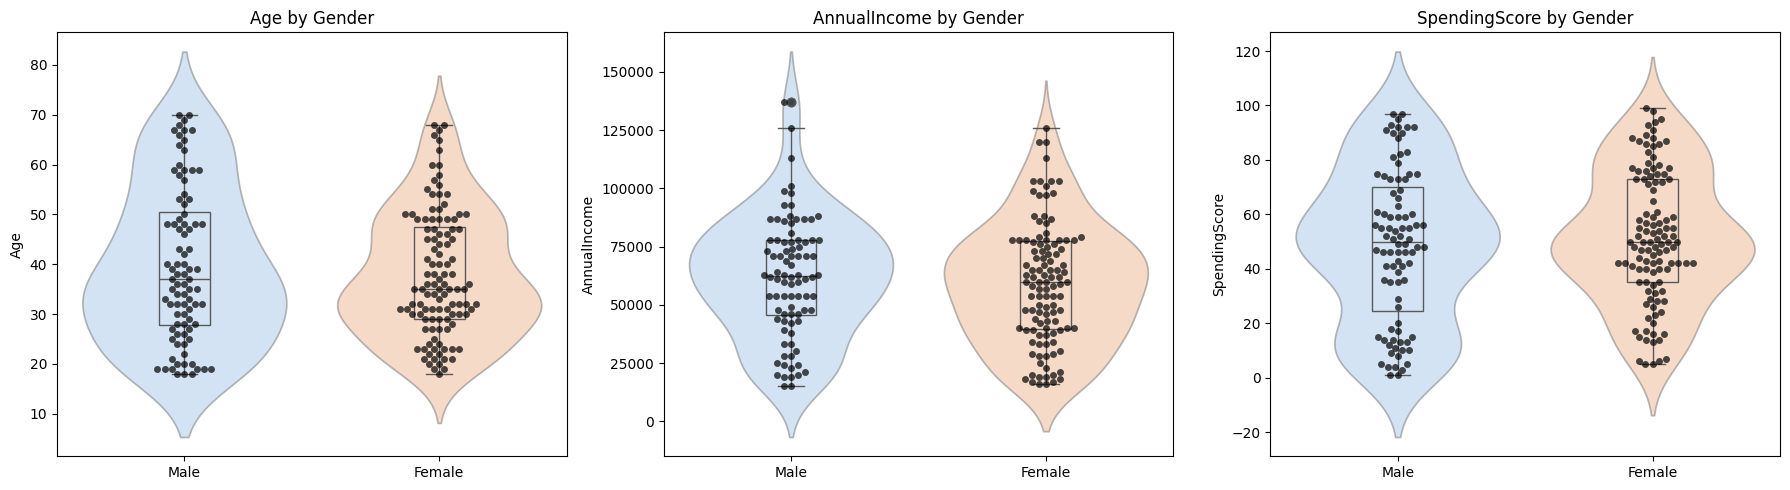

In [31]:
# Combined plot: Box + Violin + Swarm

plt.figure(figsize=(18, 5))
for i, feature in enumerate(numerical_cols):
    plt.subplot(1, 3, i+1)
    
    # Violin plot (distribution + density)
    sns.violinplot(x='Gender', y=feature, data=df, inner=None, hue='Gender', palette='pastel', alpha=0.5, legend=False)
    
    # Boxplot (quartiles + median)
    sns.boxplot(x='Gender', y=feature, data=df, width=0.2, hue='Gender', palette='Set2', showcaps=True, boxprops={'facecolor':'None'}, showfliers=True, legend=False)
    
    # Swarmplot (individual points)
    sns.swarmplot(x='Gender', y=feature, data=df, color='k', alpha=0.7)
    
    plt.title(f'{feature} by Gender')
    plt.xlabel('')
    plt.ylabel(feature)
    
plt.tight_layout()
plt.show()


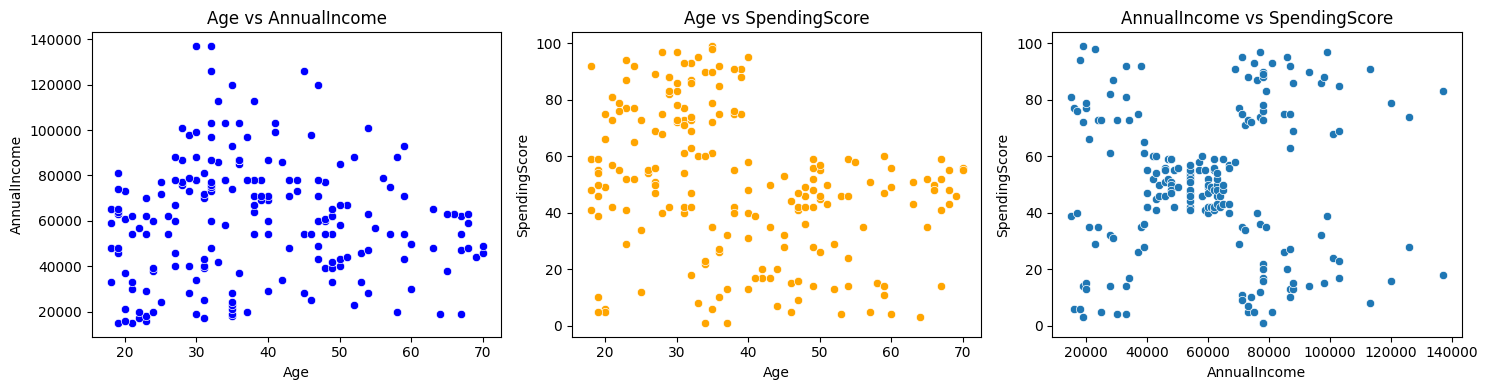

In [32]:
# Individual scatter plots
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.scatterplot(x='Age', y='AnnualIncome', data=df, c = 'blue')
plt.title('Age vs AnnualIncome')

plt.subplot(1, 3, 2)
sns.scatterplot(x='Age', y='SpendingScore', data=df, c = 'orange')
plt.title('Age vs SpendingScore')

plt.subplot(1, 3, 3)
sns.scatterplot(x='AnnualIncome', y='SpendingScore', data=df)
plt.title('AnnualIncome vs SpendingScore')

plt.tight_layout()
plt.show()

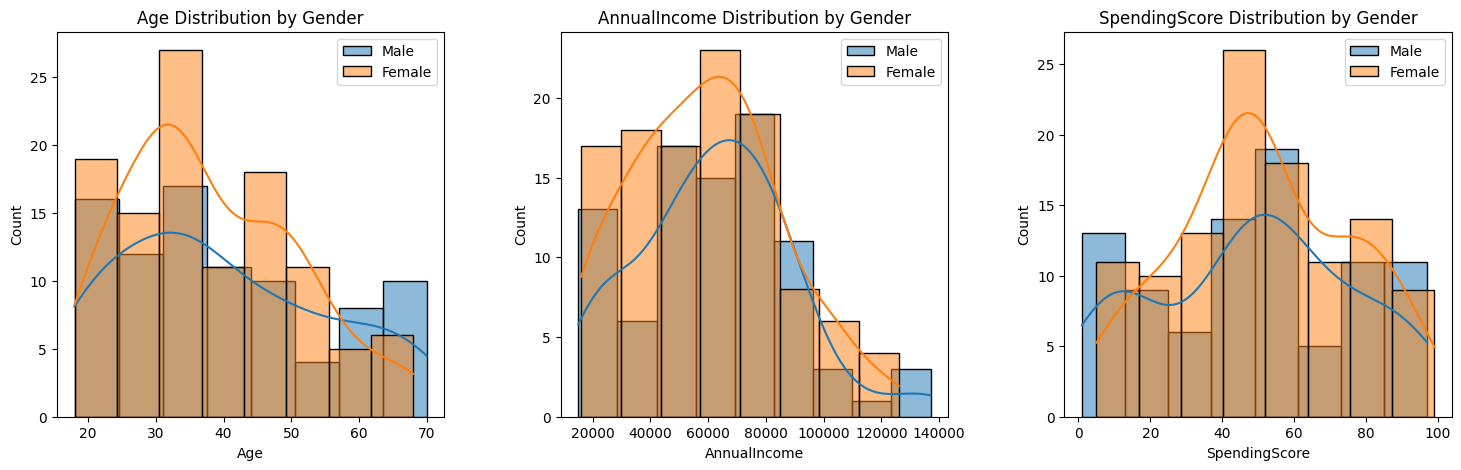

In [33]:
# Distribution plots by category (Optional)
plt.figure(figsize=(18, 5))
for i, feature in enumerate(numerical_cols):
    plt.subplot(1, 3, i+1)
    for gender in df['Gender'].unique():
        sns.histplot(df[df['Gender']==gender][feature], label=gender, kde=True, alpha=0.5)
    plt.title(f'{feature} Distribution by Gender')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.legend()
plt.subplots_adjust(wspace=0.3, hspace=0.3)  
plt.show()


## Multivariate Analysis

 Numerical messures

In [34]:
corr_pearson = df[numerical_cols].corr(method='pearson')
corr_spearman = df[numerical_cols].corr(method='spearman')
corr_kendall = df[numerical_cols].corr(method='kendall')

print("Pearson Correlation:\n", corr_pearson)
print("\nSpearman Correlation:\n", corr_spearman)
print("\nKendall Correlation:\n", corr_kendall)


Pearson Correlation:
                     Age  AnnualIncome  SpendingScore
Age            1.000000     -0.012398      -0.327227
AnnualIncome  -0.012398      1.000000       0.009903
SpendingScore -0.327227      0.009903       1.000000

Spearman Correlation:
                     Age  AnnualIncome  SpendingScore
Age            1.000000      0.019767       -0.34494
AnnualIncome   0.019767      1.000000        0.00784
SpendingScore -0.344940      0.007840        1.00000

Kendall Correlation:
                     Age  AnnualIncome  SpendingScore
Age            1.000000      0.008198      -0.210757
AnnualIncome   0.008198      1.000000      -0.000765
SpendingScore -0.210757     -0.000765       1.000000


Shows joint variability of features.

In [35]:
cov_matrix = df[numerical_cols].cov()
print("Covariance Matrix:\n", cov_matrix)


Covariance Matrix:
                        Age  AnnualIncome  SpendingScore
Age             195.133166 -4.548744e+03    -118.040201
AnnualIncome  -4548.743719  6.898356e+08    6716.582915
SpendingScore  -118.040201  6.716583e+03     666.854271


(c) Multicollinearity Check (VIF)

Variance Inflation Factor (VIF) tells if a variable is highly correlated with others.

In [36]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X = df[numerical_cols]
X = sm.add_constant(X)  # add intercept
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)


         Feature        VIF
0          const  23.359560
1            Age   1.120023
2   AnnualIncome   1.000192
3  SpendingScore   1.119961


d) Mahalanobis Distance

Multivariate distance measure (accounts for correlations).
Useful for checking multivariate outliers.

In [37]:
from scipy.spatial import distance

cov_matrix = np.cov(df[numerical_cols].values.T)
inv_cov_matrix = np.linalg.inv(cov_matrix)
mean_vals = df[numerical_cols].mean(axis=0).values

df['MahalanobisDist'] = df[numerical_cols].apply(
    lambda x: distance.mahalanobis(x, mean_vals, inv_cov_matrix), axis=1
)
print(df['MahalanobisDist'].describe())


count    200.000000
mean       1.617170
std        0.609607
min        0.268838
25%        1.161438
50%        1.625940
75%        2.035125
max        3.308906
Name: MahalanobisDist, dtype: float64


2. For Numerical + Categorical
(a) Group-Wise Descriptive Stats

Numerical features grouped by categorical

In [38]:
group_stats = df.groupby('Gender')[numerical_cols].agg(['mean','std','min','max'])
print(group_stats)


              Age                     AnnualIncome                       \
             mean        std min max          mean           std    min   
Gender                                                                    
Female  38.098214  12.644095  18  68  59250.000000  26011.951515  16000   
Male    39.806818  15.514812  18  70  62227.272727  26638.373182  15000   

               SpendingScore                    
           max          mean       std min max  
Gender                                          
Female  126000     51.526786  24.11495   5  99  
Male    137000     48.511364  27.89677   1  97  


(b) Multivariate ANOVA (MANOVA)

Tests whether the categorical variable (Gender) significantly explains variance across all numerical features jointly.

In [39]:
from statsmodels.multivariate.manova import MANOVA

formula = 'Age + AnnualIncome + SpendingScore ~ Gender'
maov = MANOVA.from_formula(formula, data=df)
print(maov.mv_test())


                   Multivariate linear model
                                                               
---------------------------------------------------------------
       Intercept         Value  Num DF  Den DF  F Value  Pr > F
---------------------------------------------------------------
          Wilks' lambda  0.0748 3.0000 196.0000 807.6801 0.0000
         Pillai's trace  0.9252 3.0000 196.0000 807.6801 0.0000
 Hotelling-Lawley trace 12.3625 3.0000 196.0000 807.6801 0.0000
    Roy's greatest root 12.3625 3.0000 196.0000 807.6801 0.0000
---------------------------------------------------------------
                                                               
---------------------------------------------------------------
           Gender         Value  Num DF  Den DF  F Value Pr > F
---------------------------------------------------------------
            Wilks' lambda 0.9914 3.0000 196.0000  0.5691 0.6360
           Pillai's trace 0.0086 3.0000 196.0000  0.5691 0.

c) Chi-Square Test with Binned Features (Optional)

If you bin numerical features (e.g., low/medium/high income), you can test association with gender.

In [40]:
df['IncomeGroup'] = pd.qcut(df['AnnualIncome'], q=3, labels=['Low','Medium','High'])
cont_table = pd.crosstab(df['Gender'], df['IncomeGroup'])
chi2, p, dof, ex = stats.chi2_contingency(cont_table)
print("Chi-square Test: chi2=%.3f, p=%.3f" % (chi2, p))


Chi-square Test: chi2=0.736, p=0.692


✅ Summary of Numerical Measures You’ll Get

Correlation (Pearson/Spearman/Kendall) → strength & direction of relationships.

Covariance Matrix → raw joint variability.

VIF → detect multicollinearity.

Mahalanobis Distance → multivariate outlier check.

Group Stats by Gender → mean/std/min/max across groups.

MANOVA → joint test of categorical effect on multiple numerical features.

Chi-square (optional) → categorical-numerical association (after binning).

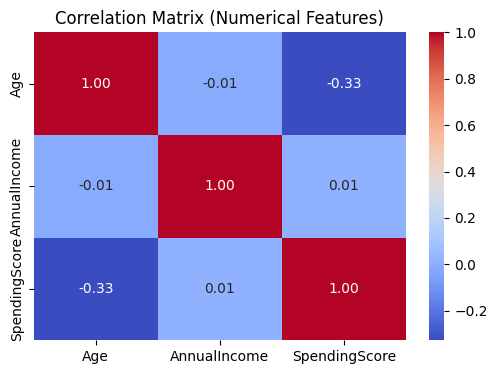

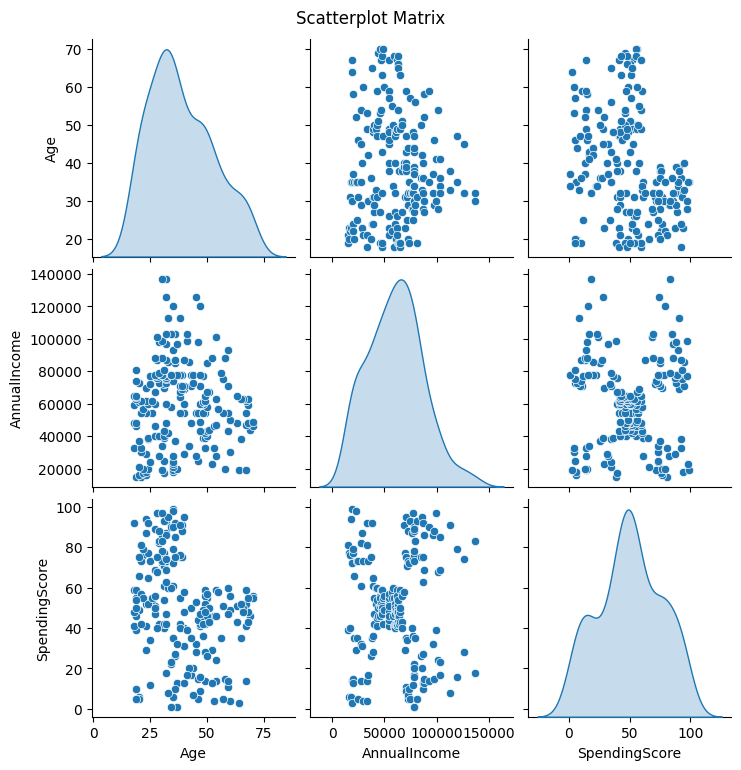

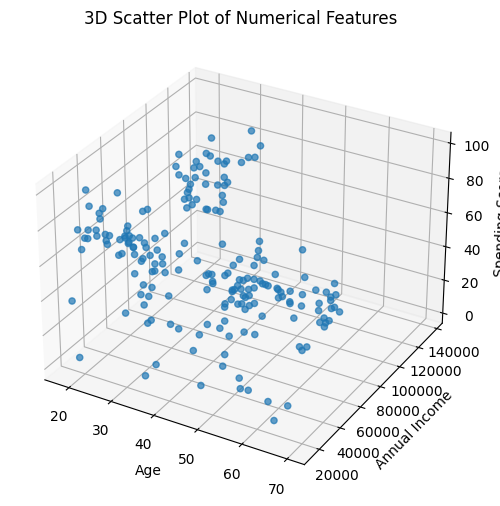

Grouped Statistics by Gender:
               Age                            AnnualIncome           \
             mean median        std min max          mean   median   
Gender                                                               
Female  38.098214   35.0  12.644095  18  68  59250.000000  60000.0   
Male    39.806818   37.0  15.514812  18  70  62227.272727  62500.0   

                                    SpendingScore                           
                 std    min     max          mean median       std min max  
Gender                                                                      
Female  26011.951515  16000  126000     51.526786   50.0  24.11495   5  99  
Male    26638.373182  15000  137000     48.511364   50.0  27.89677   1  97  


C:\Users\anilj.ANIL_JOSEPH\AppData\Local\Temp\ipykernel_30216\1099531823.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y=col, data=df, palette="Set2")


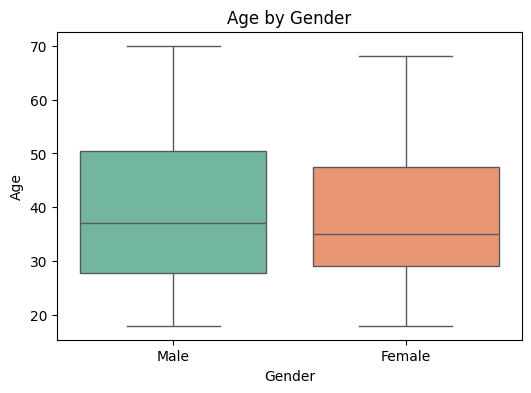

C:\Users\anilj.ANIL_JOSEPH\AppData\Local\Temp\ipykernel_30216\1099531823.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y=col, data=df, palette="Set2")


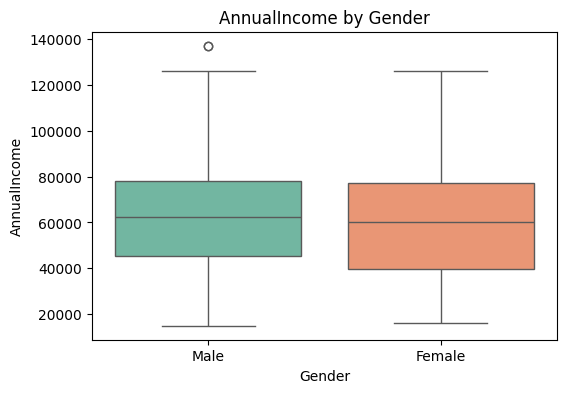

C:\Users\anilj.ANIL_JOSEPH\AppData\Local\Temp\ipykernel_30216\1099531823.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y=col, data=df, palette="Set2")


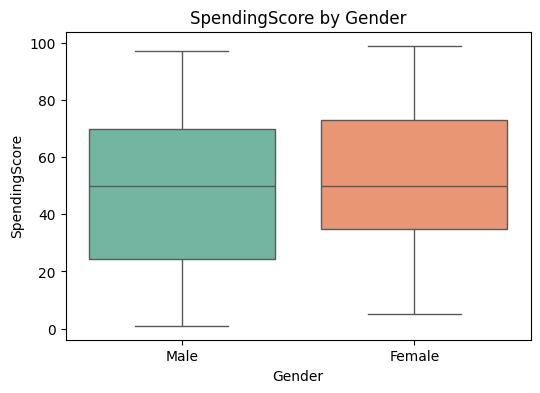

                   Multivariate linear model
                                                               
---------------------------------------------------------------
       Intercept         Value  Num DF  Den DF  F Value  Pr > F
---------------------------------------------------------------
          Wilks' lambda  0.0748 3.0000 196.0000 807.6801 0.0000
         Pillai's trace  0.9252 3.0000 196.0000 807.6801 0.0000
 Hotelling-Lawley trace 12.3625 3.0000 196.0000 807.6801 0.0000
    Roy's greatest root 12.3625 3.0000 196.0000 807.6801 0.0000
---------------------------------------------------------------
                                                               
---------------------------------------------------------------
           Gender         Value  Num DF  Den DF  F Value Pr > F
---------------------------------------------------------------
            Wilks' lambda 0.9914 3.0000 196.0000  0.5691 0.6360
           Pillai's trace 0.0086 3.0000 196.0000  0.5691 0.

NameError: name 'StandardScaler' is not defined

In [41]:
# ------------------------------
# 3. Numerical MVA
# ------------------------------

## 3.1 Correlation Matrix
corr = df[numerical_cols].corr(method='pearson')
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (Numerical Features)")
plt.show()

## 3.2 Scatterplot Matrix (Pairplot)
sns.pairplot(df[numerical_cols], diag_kind='kde')
plt.suptitle("Scatterplot Matrix", y=1.02)
plt.show()

## 3.3 3D Scatter Plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['Age'], df['AnnualIncome'], df['SpendingScore'], alpha=0.7)
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income')
ax.set_zlabel('Spending Score')
plt.title("3D Scatter Plot of Numerical Features")
plt.show()

# ------------------------------
# 4. Numerical + Categorical MVA
# ------------------------------

## 4.1 Grouped Statistics
grouped_stats = df.groupby('Gender')[numerical_cols].agg(['mean','median','std','min','max'])
print("Grouped Statistics by Gender:\n", grouped_stats)

## 4.2 Boxplots
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Gender', y=col, data=df, palette="Set2")
    plt.title(f"{col} by Gender")
    plt.show()

## 4.3 MANOVA (Multivariate ANOVA)
# Check if Gender explains variance across multiple numerical features
formula = 'Age + AnnualIncome + SpendingScore ~ Gender'
maov = MANOVA.from_formula(formula, data=df)
print(maov.mv_test())

# ------------------------------
# 5. Combined MVA (Overall)
# ------------------------------

## 5.1 Standardize Data for PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numerical_cols])

## 5.2 PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
df['PCA1'], df['PCA2'] = pca_result[:,0], pca_result[:,1]

print("Explained Variance Ratio by PCA:", pca.explained_variance_ratio_)

## 5.3 PCA Scatterplot
plt.figure(figsize=(6,4))
sns.scatterplot(x="PCA1", y="PCA2", hue="Gender", data=df, palette="Set1", alpha=0.7)
plt.title("PCA Scatterplot (2D Projection)")
plt.show()

# ------------------------------
# 6. Optional Advanced Visualization
# ------------------------------

## 6.1 Pairplot Colored by Gender
sns.pairplot(df, vars=numerical_cols, hue="Gender", diag_kind='kde', palette="Set1")
plt.suptitle("Pairplot by Gender", y=1.02)
plt.show()

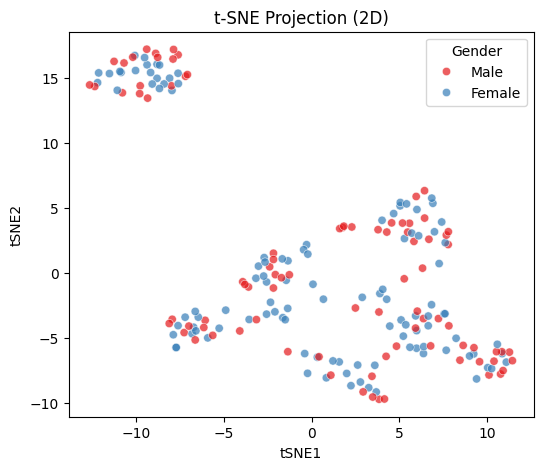

TypeError: check_array() got an unexpected keyword argument 'ensure_all_finite'

In [ ]:
from sklearn.manifold import TSNE
import umap.umap_ as umap
from sklearn.preprocessing import StandardScaler

# ==============================
# Non-Linear Dimensionality Reduction
# ==============================

from sklearn.manifold import TSNE
import umap.umap_ as umap
from sklearn.preprocessing import StandardScaler

# Scale numerical data (important for distance-based methods)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numerical_cols])

# --------------------------------
# 1. t-SNE (t-Distributed Stochastic Neighbor Embedding)
# --------------------------------
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
tsne_result = tsne.fit_transform(X_scaled)

df['tSNE1'], df['tSNE2'] = tsne_result[:,0], tsne_result[:,1]

plt.figure(figsize=(6,5))
sns.scatterplot(x="tSNE1", y="tSNE2", hue="Gender", data=df, palette="Set1", alpha=0.7)
plt.title("t-SNE Projection (2D)")
plt.show()

# --------------------------------
# 2. UMAP (Uniform Manifold Approximation and Projection)
# --------------------------------
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
umap_result = umap_model.fit_transform(X_scaled)

df['UMAP1'], df['UMAP2'] = umap_result[:,0], umap_result[:,1]

plt.figure(figsize=(6,5))
sns.scatterplot(x="UMAP1", y="UMAP2", hue="Gender", data=df, palette="Set2", alpha=0.7)
plt.title("UMAP Projection (2D)")
plt.show()


=== Correlation Matrices ===
                    Age  AnnualIncome  SpendingScore
Age            1.000000     -0.012398      -0.327227
AnnualIncome  -0.012398      1.000000       0.009903
SpendingScore -0.327227      0.009903       1.000000 



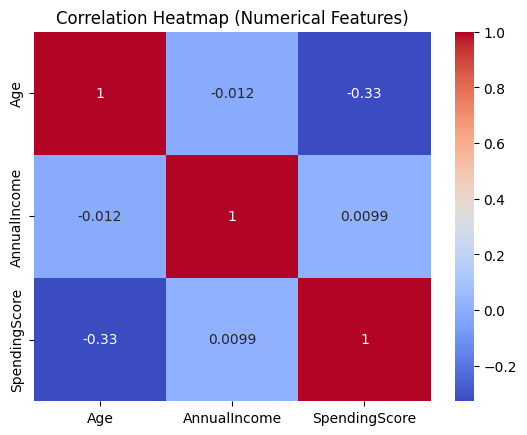

=== Covariance Matrix ===
                       Age  AnnualIncome  SpendingScore
Age             195.133166 -4.548744e+03    -118.040201
AnnualIncome  -4548.743719  6.898356e+08    6716.582915
SpendingScore  -118.040201  6.716583e+03     666.854271 

=== Variance Inflation Factor ===
          Feature        VIF
0          const  23.359560
1            Age   1.120023
2   AnnualIncome   1.000192
3  SpendingScore   1.119961 

=== Mahalanobis Distance Summary ===
 count    200.000000
mean       1.617170
std        0.609607
min        0.268838
25%        1.161438
50%        1.625940
75%        2.035125
max        3.308906
Name: MahalanobisDist, dtype: float64 



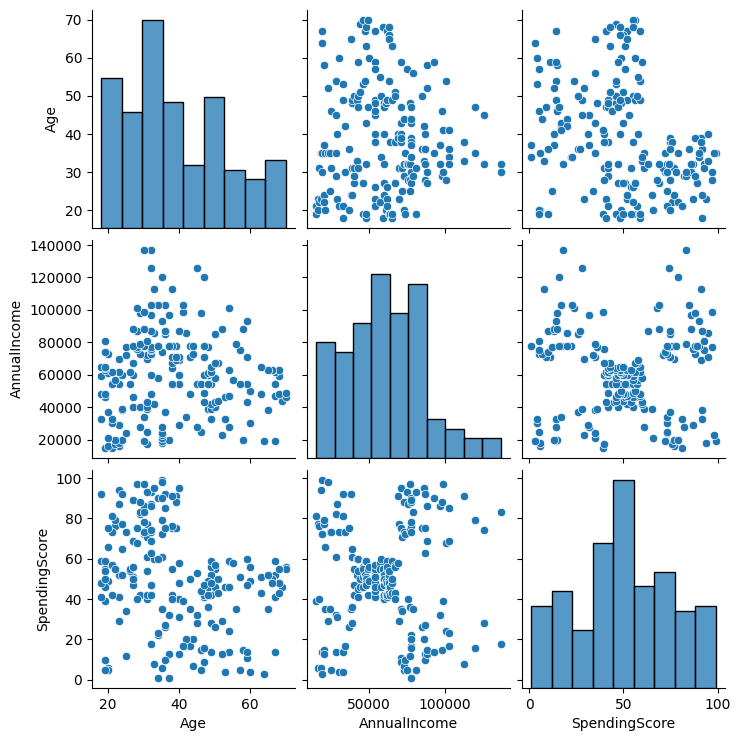

=== Group Statistics by Gender ===
               Age                     AnnualIncome                       \
             mean        std min max          mean           std    min   
Gender                                                                    
Female  38.098214  12.644095  18  68  59250.000000  26011.951515  16000   
Male    39.806818  15.514812  18  70  62227.272727  26638.373182  15000   

               SpendingScore                    
           max          mean       std min max  
Gender                                          
Female  126000     51.526786  24.11495   5  99  
Male    137000     48.511364  27.89677   1  97   

=== MANOVA Results ===
                    Multivariate linear model
                                                               
---------------------------------------------------------------
       Intercept         Value  Num DF  Den DF  F Value  Pr > F
---------------------------------------------------------------
          Wilks'

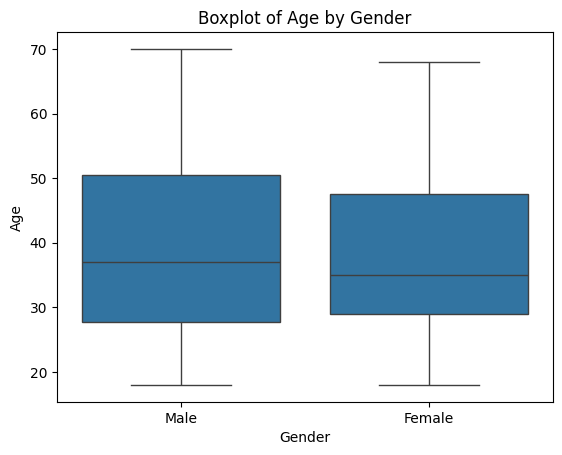

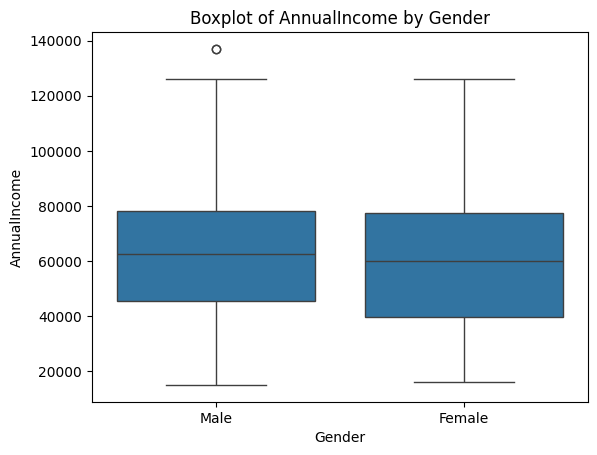

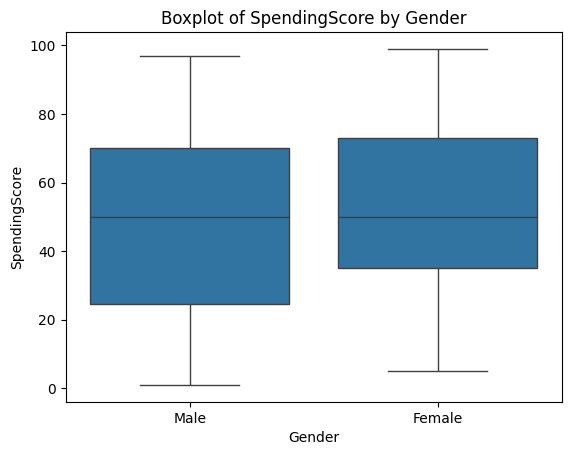

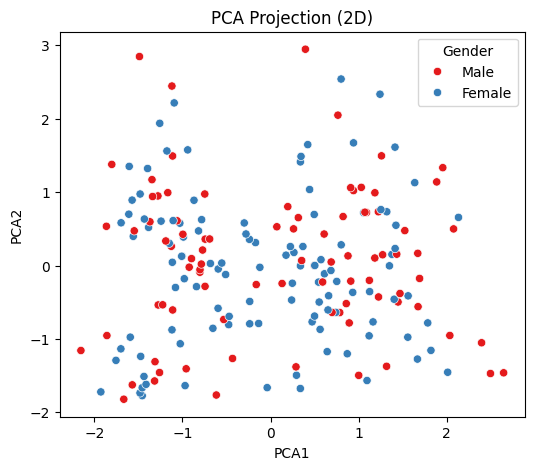

Explained Variance Ratio (PCA): [0.44266167 0.33308378]


In [ ]:
# ==========================
# Multivariate Analysis (MVA) Pipeline
# ==========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.multivariate.manova import MANOVA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --------------------------
# Setup
# --------------------------
numerical_cols = ['Age', 'AnnualIncome', 'SpendingScore']
categorical_cols = ['Gender']

# ============================================
# 1. Numerical vs Numerical
# ============================================

# (a) Correlation
print("=== Correlation Matrices ===")
print(df[numerical_cols].corr(method='pearson'), "\n")

sns.heatmap(df[numerical_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

# (b) Covariance
print("=== Covariance Matrix ===")
print(df[numerical_cols].cov(), "\n")

# (c) VIF (Variance Inflation Factor)
X = sm.add_constant(df[numerical_cols])
vif_data = pd.DataFrame({
    "Feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print("=== Variance Inflation Factor ===\n", vif_data, "\n")

# (d) Outlier Check: Mahalanobis Distance
from scipy.spatial import distance
cov_matrix = np.cov(df[numerical_cols].values.T)
inv_cov_matrix = np.linalg.inv(cov_matrix)
mean_vals = df[numerical_cols].mean(axis=0).values

df['MahalanobisDist'] = df[numerical_cols].apply(
    lambda x: distance.mahalanobis(x, mean_vals, inv_cov_matrix), axis=1
)
print("=== Mahalanobis Distance Summary ===\n", df['MahalanobisDist'].describe(), "\n")

# Scatterplot Matrix
sns.pairplot(df[numerical_cols])
plt.show()

# ============================================
# 2. Categorical vs Categorical
# ============================================

# Example: Gender vs AnotherCategory (if available)
# Chi-square + Cramer's V
if len(categorical_cols) > 1:
    cat1, cat2 = categorical_cols[0], categorical_cols[1]
    cont_table = pd.crosstab(df[cat1], df[cat2])
    chi2, p, dof, exp = stats.chi2_contingency(cont_table)
    n = cont_table.sum().sum()
    phi2 = chi2/n
    r, k = cont_table.shape
    cramers_v = np.sqrt(phi2/min(k-1, r-1))

    print(f"Chi-square({cat1} vs {cat2}) = {chi2:.3f}, p = {p:.3f}")
    print("Cramer's V:", cramers_v, "\n")

    sns.heatmap(cont_table, annot=True, cmap="Blues", fmt="d")
    plt.title(f"Crosstab Heatmap: {cat1} vs {cat2}")
    plt.show()

# ============================================
# 3. Numerical vs Categorical
# ============================================

# Grouped statistics
group_stats = df.groupby('Gender')[numerical_cols].agg(['mean','std','min','max'])
print("=== Group Statistics by Gender ===\n", group_stats, "\n")

# MANOVA
formula = " + ".join(numerical_cols) + " ~ Gender"
maov = MANOVA.from_formula(formula, data=df)
print("=== MANOVA Results ===\n", maov.mv_test(), "\n")

# Boxplots / Violin plots
for col in numerical_cols:
    sns.boxplot(x="Gender", y=col, data=df)
    plt.title(f"Boxplot of {col} by Gender")
    plt.show()

# ============================================
# 4. Dimensionality Reduction for Structure
# ============================================

# Standardize numerical data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numerical_cols])

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
df['PCA1'], df['PCA2'] = pca_result[:,0], pca_result[:,1]

plt.figure(figsize=(6,5))
sns.scatterplot(x="PCA1", y="PCA2", hue="Gender", data=df, palette="Set1")
plt.title("PCA Projection (2D)")
plt.show()

print("Explained Variance Ratio (PCA):", pca.explained_variance_ratio_)


=== Correlation Matrix ===
                    Age  AnnualIncome  SpendingScore
Age            1.000000     -0.012398      -0.327227
AnnualIncome  -0.012398      1.000000       0.009903
SpendingScore -0.327227      0.009903       1.000000


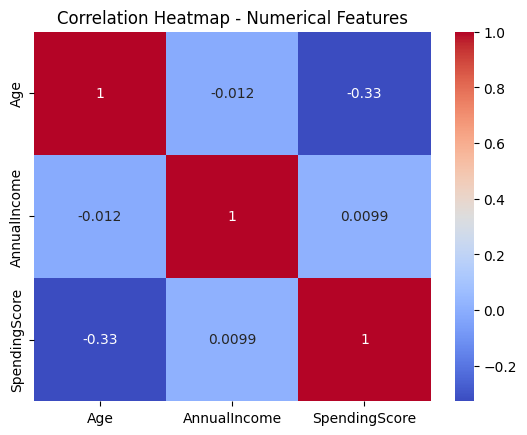

=== Variance Inflation Factor ===
         Feature        VIF
0          const  23.359560
1            Age   1.120023
2   AnnualIncome   1.000192
3  SpendingScore   1.119961


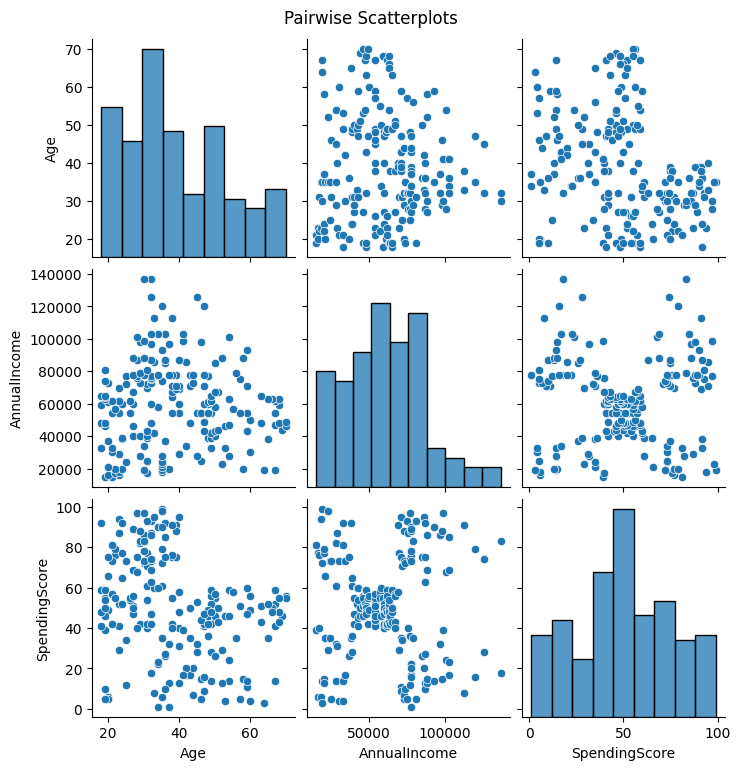

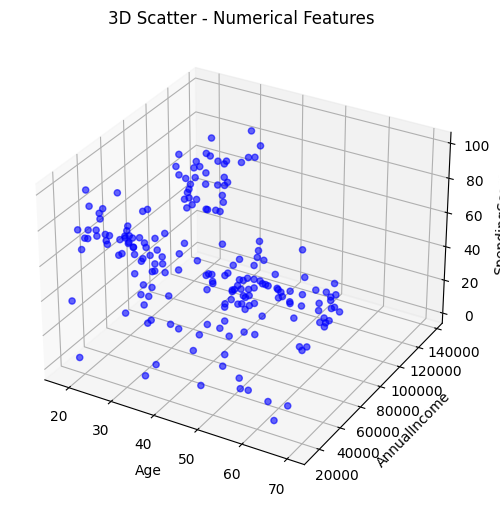

=== Group Statistics by Gender ===
              Age                     AnnualIncome                       \
             mean        std min max          mean           std    min   
Gender                                                                    
Female  38.098214  12.644095  18  68  59250.000000  26011.951515  16000   
Male    39.806818  15.514812  18  70  62227.272727  26638.373182  15000   

               SpendingScore                    
           max          mean       std min max  
Gender                                          
Female  126000     51.526786  24.11495   5  99  
Male    137000     48.511364  27.89677   1  97  


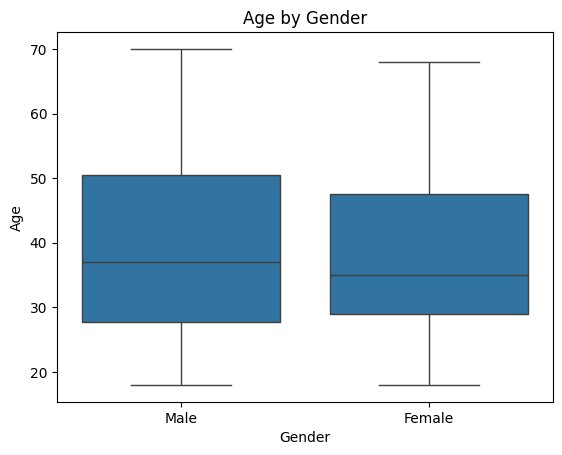

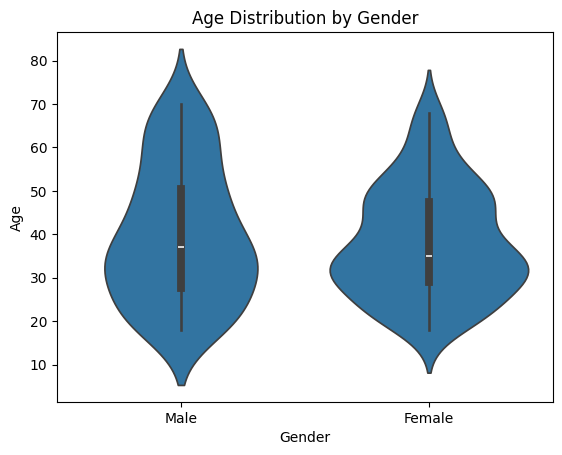

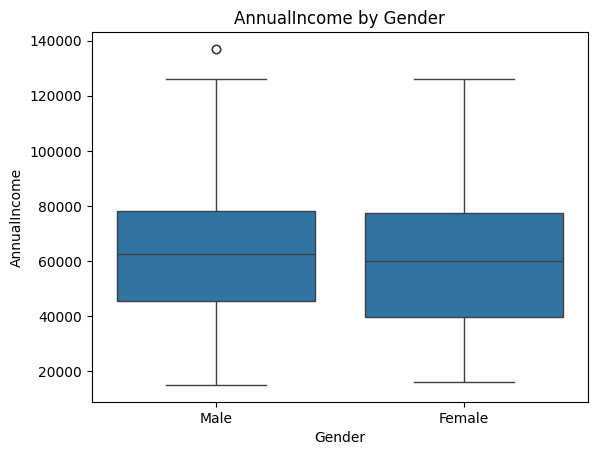

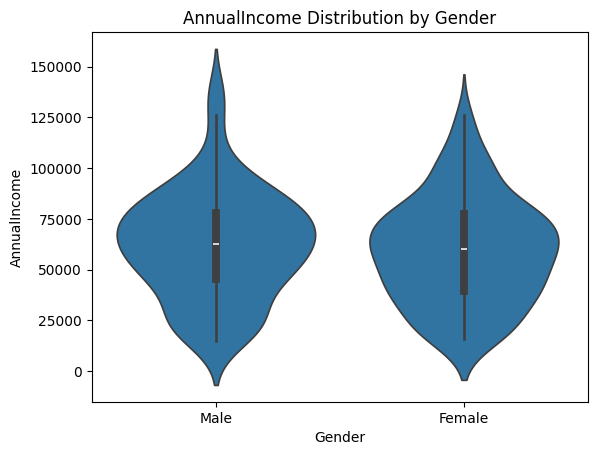

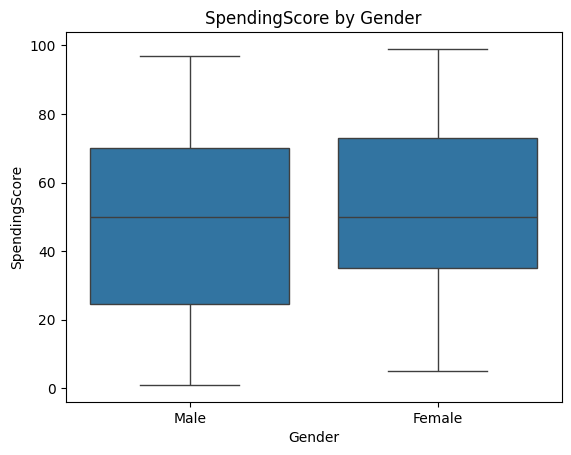

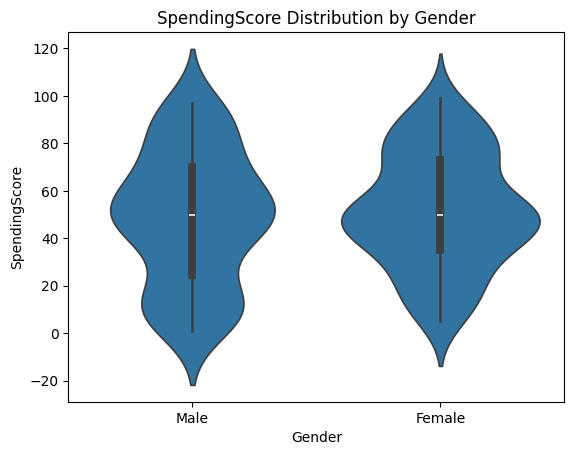

Age | t-stat: 0.86, p-value: 0.392
AnnualIncome | t-stat: 0.80, p-value: 0.428
SpendingScore | t-stat: -0.82, p-value: 0.414
=== MANOVA Results ===
                   Multivariate linear model
                                                               
---------------------------------------------------------------
       Intercept         Value  Num DF  Den DF  F Value  Pr > F
---------------------------------------------------------------
          Wilks' lambda  0.0748 3.0000 196.0000 807.6801 0.0000
         Pillai's trace  0.9252 3.0000 196.0000 807.6801 0.0000
 Hotelling-Lawley trace 12.3625 3.0000 196.0000 807.6801 0.0000
    Roy's greatest root 12.3625 3.0000 196.0000 807.6801 0.0000
---------------------------------------------------------------
                                                               
---------------------------------------------------------------
           Gender         Value  Num DF  Den DF  F Value Pr > F
---------------------------------------

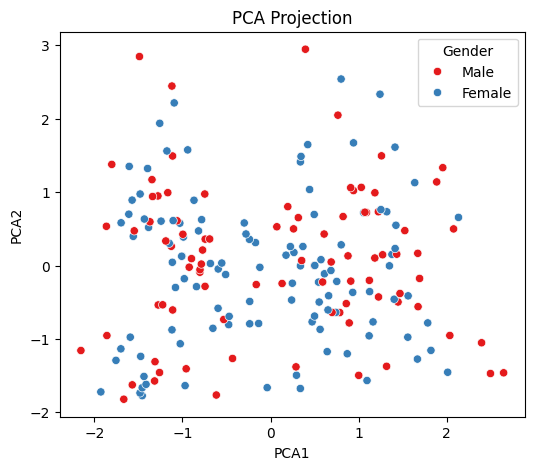

Explained Variance Ratio: [0.44266167 0.33308378]


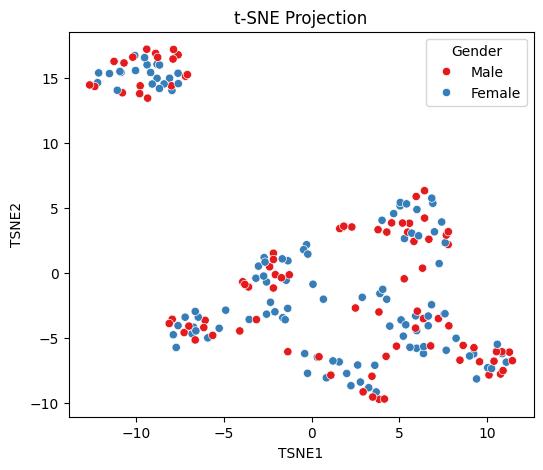

In [ ]:
# ==========================
# Multivariate Analysis (Numerical + Categorical) for Clustering
# ==========================

# --------------------------
# 1. Libraries
# --------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.multivariate.manova import MANOVA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D

# --------------------------
# 2. Dataset
# --------------------------
# Load your dataset here
# df = pd.read_csv("your_file.csv")

numerical_cols = ['Age', 'AnnualIncome', 'SpendingScore']
categorical_cols = ['Gender']

# ==========================
# 3. Numerical vs Numerical
# ==========================

print("=== Correlation Matrix ===")
corr = df[numerical_cols].corr()
print(corr)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap - Numerical Features")
plt.show()

# VIF
X = sm.add_constant(df[numerical_cols])
vif_data = pd.DataFrame({
    "Feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print("=== Variance Inflation Factor ===")
print(vif_data)

# Pairplot for numerical features
sns.pairplot(df[numerical_cols])
plt.suptitle("Pairwise Scatterplots", y=1.02)
plt.show()

# 3D Scatter Plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['Age'], df['AnnualIncome'], df['SpendingScore'], c='blue', alpha=0.6)
ax.set_xlabel('Age')
ax.set_ylabel('AnnualIncome')
ax.set_zlabel('SpendingScore')
plt.title("3D Scatter - Numerical Features")
plt.show()

# ==========================
# 4. Categorical vs Categorical
# ==========================
if len(categorical_cols) > 1:
    cat1, cat2 = categorical_cols[0], categorical_cols[1]
    contingency = pd.crosstab(df[cat1], df[cat2])
    chi2, p, dof, ex = stats.chi2_contingency(contingency)
    print(f"Chi-square ({cat1} vs {cat2}) = {chi2:.2f}, p-value = {p:.3f}")

    # Cramer's V
    n = contingency.sum().sum()
    phi2 = chi2/n
    r,k = contingency.shape
    cramers_v = np.sqrt(phi2/min(k-1,r-1))
    print("Cramer's V:", cramers_v)

    sns.heatmap(contingency, annot=True, cmap="Blues", fmt="d")
    plt.title(f"Crosstab Heatmap: {cat1} vs {cat2}")
    plt.show()

# ==========================
# 5. Numerical vs Categorical
# ==========================

# Grouped statistics
group_stats = df.groupby('Gender')[numerical_cols].agg(['mean','std','min','max'])
print("=== Group Statistics by Gender ===")
print(group_stats)

# Boxplots / Violin plots
for col in numerical_cols:
    sns.boxplot(x='Gender', y=col, data=df)
    plt.title(f"{col} by Gender")
    plt.show()
    
    sns.violinplot(x='Gender', y=col, data=df)
    plt.title(f"{col} Distribution by Gender")
    plt.show()

# t-test between 2 categories
for feature in numerical_cols:
    male_vals = df[df['Gender']=='Male'][feature]
    female_vals = df[df['Gender']=='Female'][feature]
    t_stat, p_val = stats.ttest_ind(male_vals, female_vals)
    print(f"{feature} | t-stat: {t_stat:.2f}, p-value: {p_val:.3f}")

# MANOVA
formula = " + ".join(numerical_cols) + " ~ Gender"
maov = MANOVA.from_formula(formula, data=df)
print("=== MANOVA Results ===")
print(maov.mv_test())

# ==========================
# 6. Dimensionality Reduction / Cluster Visualization
# ==========================

# Standardize numerical data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numerical_cols])

# PCA
pca = PCA(n_components=2)
pca_res = pca.fit_transform(X_scaled)
df['PCA1'], df['PCA2'] = pca_res[:,0], pca_res[:,1]

plt.figure(figsize=(6,5))
sns.scatterplot(x='PCA1', y='PCA2', hue='Gender', data=df, palette="Set1")
plt.title("PCA Projection")
plt.show()
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# t-SNE (non-linear)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_res = tsne.fit_transform(X_scaled)
df['TSNE1'], df['TSNE2'] = tsne_res[:,0], tsne_res[:,1]

plt.figure(figsize=(6,5))
sns.scatterplot(x='TSNE1', y='TSNE2', hue='Gender', data=df, palette="Set1")
plt.title("t-SNE Projection")
plt.show()



=== Correlation Matrix ===
                    Age  AnnualIncome  SpendingScore
Age            1.000000     -0.012398      -0.327227
AnnualIncome  -0.012398      1.000000       0.009903
SpendingScore -0.327227      0.009903       1.000000


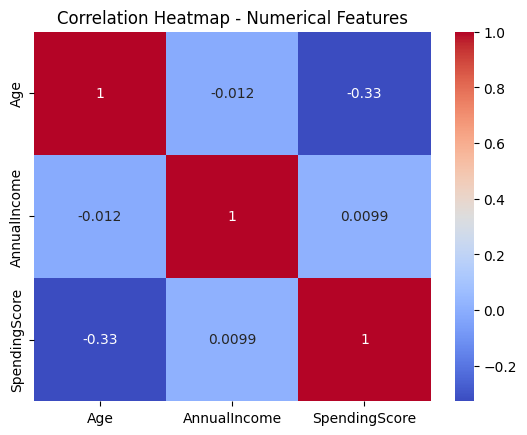

=== Variance Inflation Factor ===
         Feature        VIF
0          const  23.359560
1            Age   1.120023
2   AnnualIncome   1.000192
3  SpendingScore   1.119961


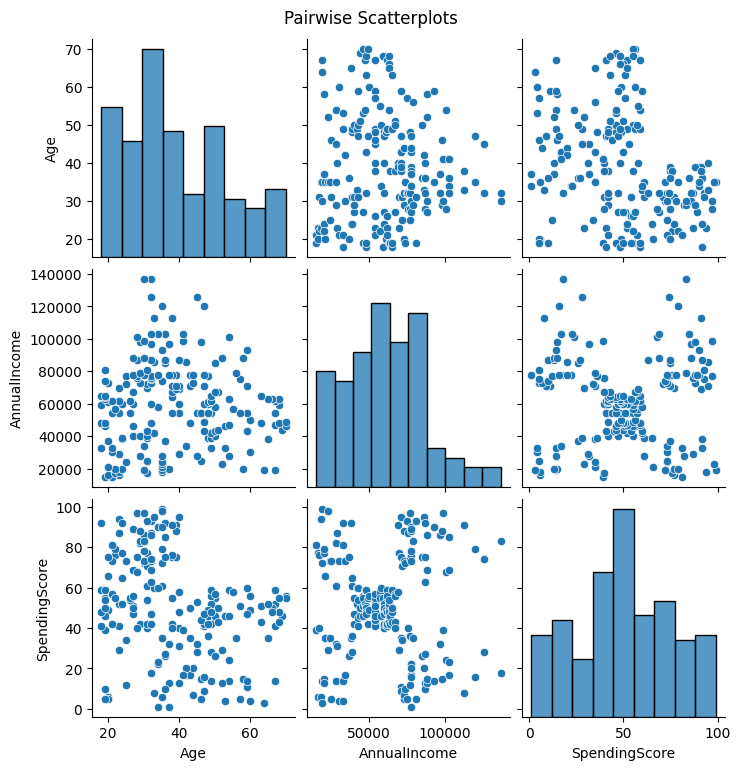

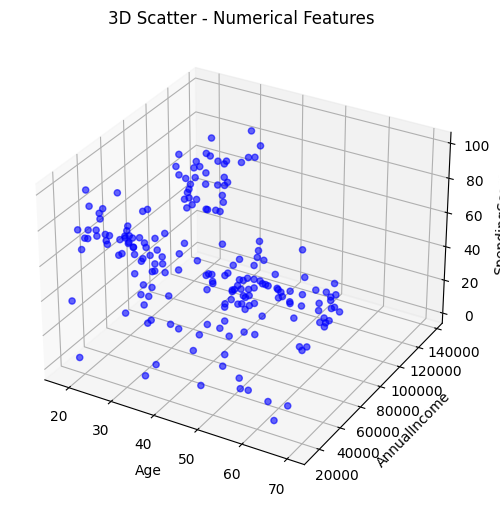

=== Group Statistics by Gender ===
              Age                     AnnualIncome                       \
             mean        std min max          mean           std    min   
Gender                                                                    
Female  38.098214  12.644095  18  68  59250.000000  26011.951515  16000   
Male    39.806818  15.514812  18  70  62227.272727  26638.373182  15000   

               SpendingScore                    
           max          mean       std min max  
Gender                                          
Female  126000     51.526786  24.11495   5  99  
Male    137000     48.511364  27.89677   1  97  


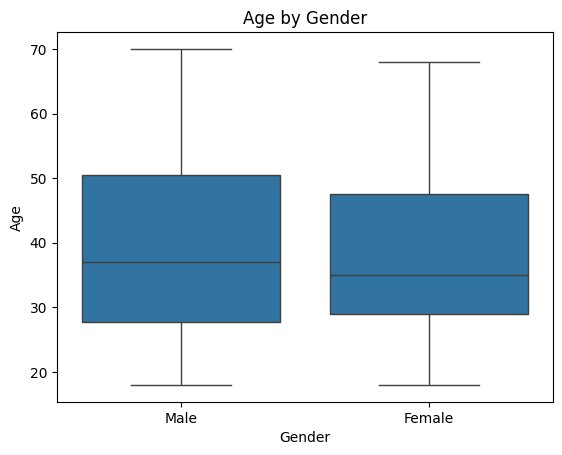

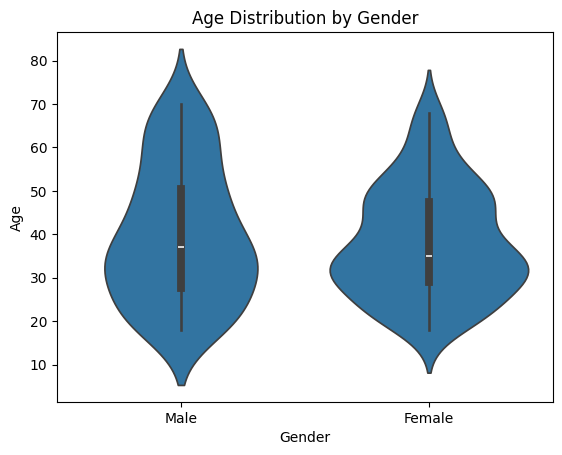

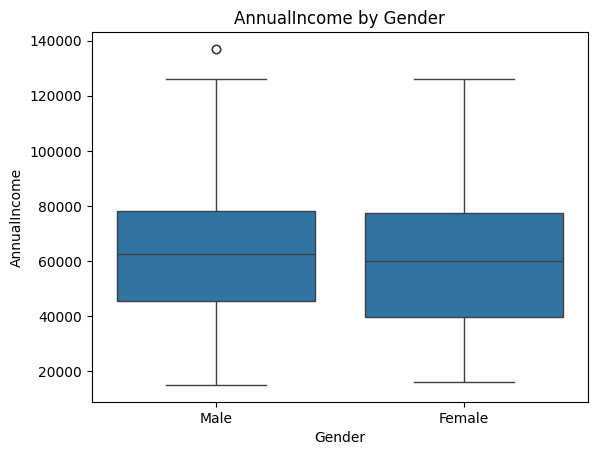

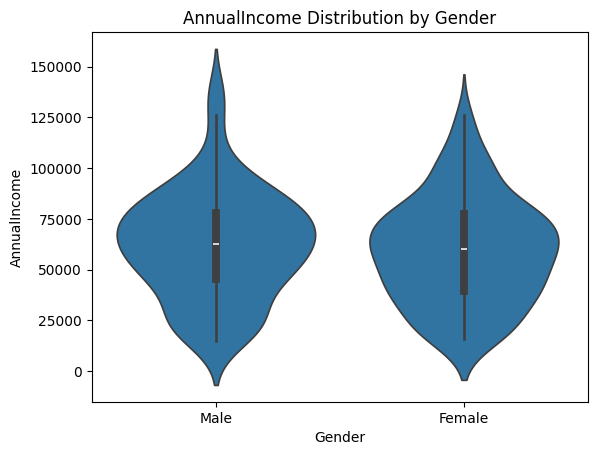

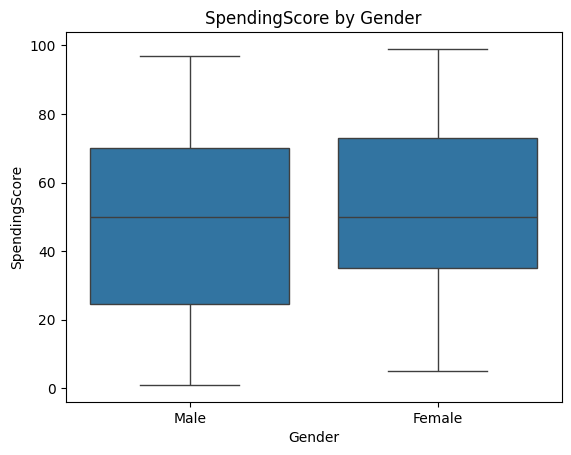

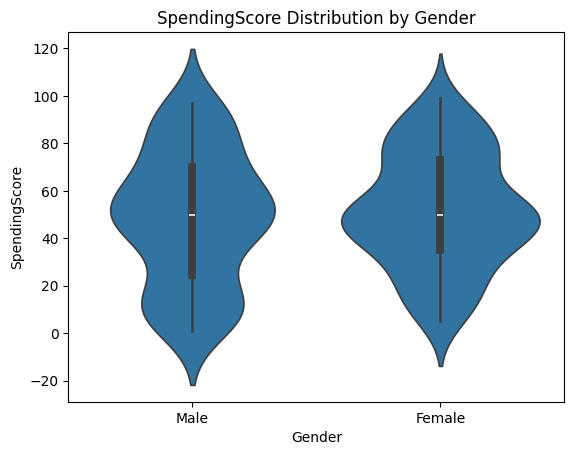

Age | t-stat: 0.86, p-value: 0.392
AnnualIncome | t-stat: 0.80, p-value: 0.428
SpendingScore | t-stat: -0.82, p-value: 0.414
=== MANOVA Results ===
                   Multivariate linear model
                                                               
---------------------------------------------------------------
       Intercept         Value  Num DF  Den DF  F Value  Pr > F
---------------------------------------------------------------
          Wilks' lambda  0.0748 3.0000 196.0000 807.6801 0.0000
         Pillai's trace  0.9252 3.0000 196.0000 807.6801 0.0000
 Hotelling-Lawley trace 12.3625 3.0000 196.0000 807.6801 0.0000
    Roy's greatest root 12.3625 3.0000 196.0000 807.6801 0.0000
---------------------------------------------------------------
                                                               
---------------------------------------------------------------
           Gender         Value  Num DF  Den DF  F Value Pr > F
---------------------------------------

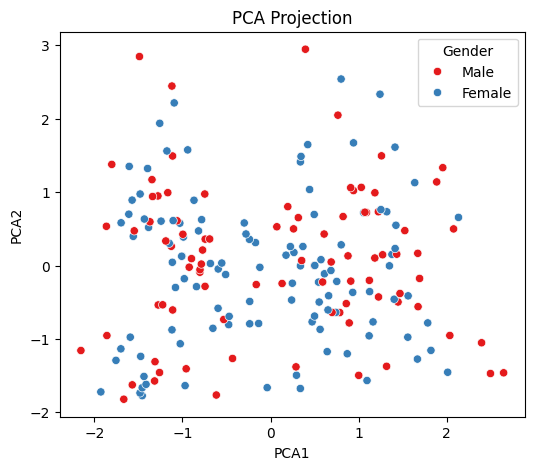

Explained Variance Ratio: [0.44266167 0.33308378]


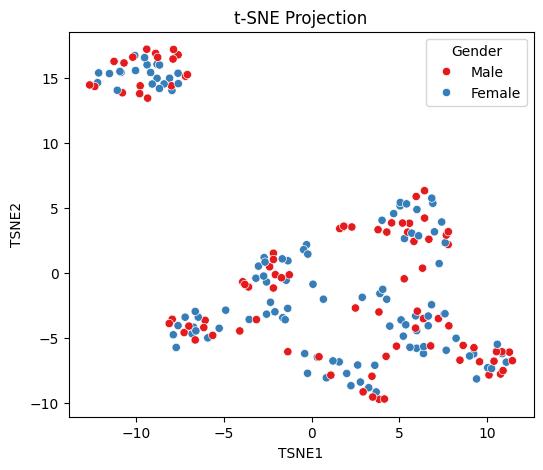

Hopkins Statistic: 0.976
K=2, Silhouette Score: 0.335
K=3, Silhouette Score: 0.358
K=4, Silhouette Score: 0.404
K=5, Silhouette Score: 0.408


In [46]:
# ==========================
# Full Multivariate Analysis + Cluster Tendency
# ==========================

# --------------------------
# 1. Libraries
# --------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.multivariate.manova import MANOVA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D

# --------------------------
# 2. Dataset
# --------------------------
# df = pd.read_csv("your_file.csv")  # Load your dataset
numerical_cols = ['Age', 'AnnualIncome', 'SpendingScore']
categorical_cols = ['Gender']

# ==========================
# 3. Numerical vs Numerical
# ==========================
print("=== Correlation Matrix ===")
corr = df[numerical_cols].corr()
print(corr)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap - Numerical Features")
plt.show()

# VIF
X = sm.add_constant(df[numerical_cols])
vif_data = pd.DataFrame({
    "Feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print("=== Variance Inflation Factor ===")
print(vif_data)

# Pairplot
sns.pairplot(df[numerical_cols])
plt.suptitle("Pairwise Scatterplots", y=1.02)
plt.show()

# 3D Scatter
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['Age'], df['AnnualIncome'], df['SpendingScore'], c='blue', alpha=0.6)
ax.set_xlabel('Age')
ax.set_ylabel('AnnualIncome')
ax.set_zlabel('SpendingScore')
plt.title("3D Scatter - Numerical Features")
plt.show()

# ==========================
# 4. Categorical vs Categorical
# ==========================
if len(categorical_cols) > 1:
    cat1, cat2 = categorical_cols[0], categorical_cols[1]
    contingency = pd.crosstab(df[cat1], df[cat2])
    chi2, p, dof, ex = stats.chi2_contingency(contingency)
    print(f"Chi-square ({cat1} vs {cat2}) = {chi2:.2f}, p-value = {p:.3f}")
    
    # Cramer's V
    n = contingency.sum().sum()
    phi2 = chi2/n
    r,k = contingency.shape
    cramers_v = np.sqrt(phi2/min(k-1,r-1))
    print("Cramer's V:", cramers_v)

    sns.heatmap(contingency, annot=True, cmap="Blues", fmt="d")
    plt.title(f"Crosstab Heatmap: {cat1} vs {cat2}")
    plt.show()

# ==========================
# 5. Numerical vs Categorical
# ==========================
# Grouped statistics
group_stats = df.groupby('Gender')[numerical_cols].agg(['mean','std','min','max'])
print("=== Group Statistics by Gender ===")
print(group_stats)

# Boxplots / Violin plots
for col in numerical_cols:
    sns.boxplot(x='Gender', y=col, data=df)
    plt.title(f"{col} by Gender")
    plt.show()
    
    sns.violinplot(x='Gender', y=col, data=df)
    plt.title(f"{col} Distribution by Gender")
    plt.show()

# t-test
for feature in numerical_cols:
    male_vals = df[df['Gender']=='Male'][feature]
    female_vals = df[df['Gender']=='Female'][feature]
    t_stat, p_val = stats.ttest_ind(male_vals, female_vals)
    print(f"{feature} | t-stat: {t_stat:.2f}, p-value: {p_val:.3f}")

# MANOVA
formula = " + ".join(numerical_cols) + " ~ Gender"
maov = MANOVA.from_formula(formula, data=df)
print("=== MANOVA Results ===")
print(maov.mv_test())

# ==========================
# 6. Dimensionality Reduction
# ==========================
# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numerical_cols])

# PCA
pca = PCA(n_components=2)
pca_res = pca.fit_transform(X_scaled)
df['PCA1'], df['PCA2'] = pca_res[:,0], pca_res[:,1]

plt.figure(figsize=(6,5))
sns.scatterplot(x='PCA1', y='PCA2', hue='Gender', data=df, palette="Set1")
plt.title("PCA Projection")
plt.show()
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_res = tsne.fit_transform(X_scaled)
df['TSNE1'], df['TSNE2'] = tsne_res[:,0], tsne_res[:,1]

plt.figure(figsize=(6,5))
sns.scatterplot(x='TSNE1', y='TSNE2', hue='Gender', data=df, palette="Set1")
plt.title("t-SNE Projection")
plt.show()

# ==========================
# 7. Cluster Tendency - Hopkins Statistic
# ==========================
def hopkins_statistic(X):
    X = np.array(X)
    n, d = X.shape
    m = int(0.1 * n)
    np.random.seed(42)
    
    random_points = np.random.uniform(np.min(X, axis=0), np.max(X, axis=0), (m,d))
    
    nbrs = NearestNeighbors(n_neighbors=1).fit(X)
    u_distances, _ = nbrs.kneighbors(random_points)
    w_distances, _ = nbrs.kneighbors(X[np.random.choice(n,m,replace=False)], n_neighbors=2)
    
    H = np.sum(u_distances) / (np.sum(u_distances) + np.sum(w_distances[:,1]))
    return H

hopkins_score = hopkins_statistic(df[numerical_cols])
print(f"Hopkins Statistic: {hopkins_score:.3f}")

# ==========================
# 8. Silhouette Score Pre-check
# ==========================
for k in range(2,6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k}, Silhouette Score: {score:.3f}")


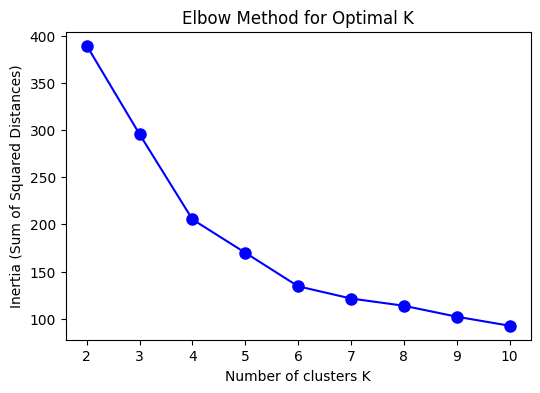

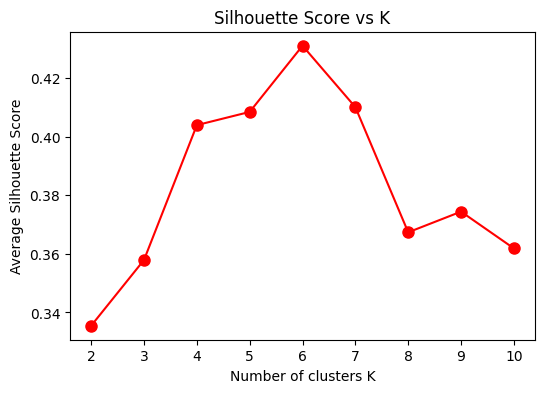

Suggested optimal K based on Silhouette Score: 6


In [47]:
# ==========================
# 9. Optimal K Suggestion for KMeans
# ==========================
inertia = []
sil_scores = []

K_range = range(2,11)  # try K=2 to 10

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# ---- Elbow Method ----
plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, 'bo-', markersize=8)
plt.xlabel("Number of clusters K")
plt.ylabel("Inertia (Sum of Squared Distances)")
plt.title("Elbow Method for Optimal K")
plt.show()

# ---- Silhouette Score ----
plt.figure(figsize=(6,4))
plt.plot(K_range, sil_scores, 'ro-', markersize=8)
plt.xlabel("Number of clusters K")
plt.ylabel("Average Silhouette Score")
plt.title("Silhouette Score vs K")
plt.show()

# Print best K according to silhouette
best_k = K_range[np.argmax(sil_scores)]
print(f"Suggested optimal K based on Silhouette Score: {best_k}")


In [48]:
def hopkins_statistic(X):
    X = np.array(X)
    n, d = X.shape
    m = int(0.1 * n)
    np.random.seed(42)
    
    random_points = np.random.uniform(np.min(X, axis=0), np.max(X, axis=0), (m,d))
    nbrs = NearestNeighbors(n_neighbors=1).fit(X)
    u_distances, _ = nbrs.kneighbors(random_points)
    w_distances, _ = nbrs.kneighbors(X[np.random.choice(n,m,replace=False)], n_neighbors=2)
    
    H = np.sum(u_distances) / (np.sum(u_distances) + np.sum(w_distances[:,1]))
    return H

hopkins_score = hopkins_statistic(df[numerical_cols])
print(f"Hopkins Statistic: {hopkins_score:.3f}")


Hopkins Statistic: 0.976


In [44]:
import sklearn
print(sklearn.__version__)


1.6.1
